# MOCs Rubin

- Dowload Rubin cadence
-    curl -O https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs5.0/maf/baseline_v5.0.1_10yrs.db
  

In [1]:
file_cadence = "/Users/dagoret/rubin_sim_data/baseline_v5.0.1_10yrs.db"

In [2]:
import sqlite3
import healpy as hp
import numpy as np

db_file = file_cadence
conn = sqlite3.connect(db_file)
cur = conn.cursor()

In [3]:
# lister les tables
cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cur.fetchall()
print([t[0] for t in tables])

['observations', 'info', 'events']


In [4]:
table_name = "observations"
cur.execute(f"PRAGMA table_info({table_name});")
cols = cur.fetchall()
for col in cols:
    print(col)

(0, 'observationId', 'INTEGER', 0, None, 0)
(1, 'fieldRA', 'REAL', 0, None, 0)
(2, 'fieldDec', 'REAL', 0, None, 0)
(3, 'observationStartMJD', 'REAL', 0, None, 0)
(4, 'flush_by_mjd', 'REAL', 0, None, 0)
(5, 'visitExposureTime', 'REAL', 0, None, 0)
(6, 'band', 'TEXT', 0, None, 0)
(7, 'filter', 'TEXT', 0, None, 0)
(8, 'rotSkyPos', 'REAL', 0, None, 0)
(9, 'rotSkyPos_desired', 'REAL', 0, None, 0)
(10, 'numExposures', 'INTEGER', 0, None, 0)
(11, 'airmass', 'REAL', 0, None, 0)
(12, 'seeingFwhm500', 'REAL', 0, None, 0)
(13, 'seeingFwhmEff', 'REAL', 0, None, 0)
(14, 'seeingFwhmGeom', 'REAL', 0, None, 0)
(15, 'skyBrightness', 'REAL', 0, None, 0)
(16, 'night', 'INTEGER', 0, None, 0)
(17, 'slewTime', 'REAL', 0, None, 0)
(18, 'visitTime', 'REAL', 0, None, 0)
(19, 'slewDistance', 'REAL', 0, None, 0)
(20, 'fiveSigmaDepth', 'REAL', 0, None, 0)
(21, 'altitude', 'REAL', 0, None, 0)
(22, 'azimuth', 'REAL', 0, None, 0)
(23, 'paraAngle', 'REAL', 0, None, 0)
(24, 'pseudoParaAngle', 'REAL', 0, None, 0)
(25, 

In [5]:
# Lister toutes les valeurs uniques de science_program
cur.execute("SELECT DISTINCT science_program FROM observations;")
programs = cur.fetchall()

# Afficher joliment
print("Science programs présents dans la DB :")
for p in programs:
    print("-", p[0])

Science programs présents dans la DB :
- None
- DD
- 


In [6]:
# Lister toutes les valeurs uniques de science_program
cur.execute("SELECT DISTINCT observation_reason FROM observations;")
programs = cur.fetchall()

# Afficher joliment
print("observation_reason présents dans la DB :")
for p in programs:
    print("-", p[0])

observation_reason présents dans la DB :
- pairs_i_5.0
- singles_r
- pairs_gr_33.0
- triplet_long_gap
- pairs_iz_15.0
- FBS
- pairs_ri_15.0
- pairs_yy_15.0
- singles_z
- singles_i
- pairs_ug_33.0
- ToO
- pairs_z_5.0
- singles_y
- pairs_zy_15.0
- pairs_r_5.0
- pairs_ri_33.0
- pairs_iz_33.0
- pairs_zy_33.0
- pairs_yy_33.0
- pairs_ur_33.0
- 


In [7]:
query = "SELECT fieldRA, fieldDEC FROM observations"
cur.execute(query)
data = np.array(cur.fetchall())

ra_list = data[:,0]
dec_list = data[:,1]

In [8]:
nside = 256
npix = hp.nside2npix(nside)

theta = np.radians(90 - dec_list)
phi = np.radians(ra_list)

pix_indices = hp.ang2pix(nside, theta, phi)

mask = np.zeros(npix, dtype=bool)
mask[pix_indices] = True

## 3. Construire le footprint Euclid

Pour la mission Euclid on utilise généralement les coupes :

|b| > 30° (galactique)

|β| > 15° (écliptique)

In [9]:
import astropy.coordinates as coord
import astropy.units as u

theta_pix, phi_pix = hp.pix2ang(nside, np.arange(npix))
ra_pix = np.degrees(phi_pix)
dec_pix = 90 - np.degrees(theta_pix)

sky = coord.SkyCoord(ra_pix*u.deg, dec_pix*u.deg)
b = sky.galactic.b.deg
beta = sky.barycentrictrueecliptic.lat.deg

euclid_mask = (np.abs(b) > 30) & (np.abs(beta) > 15)

In [10]:
overlap = mask & euclid_mask
pixarea = hp.nside2pixarea(nside, degrees=True)

print("Rubin WFD area:", mask.sum()*pixarea)
print("Euclid area:", euclid_mask.sum()*pixarea)
print("Overlap area:", overlap.sum()*pixarea)

Rubin WFD area: 21598.644945128293
Euclid area: 14210.185618775917
Overlap area: 7237.596293625671


Rubin ~18000 deg²

/Users/dagoret/miniconda3/envs/conda_py313/lib/python3.13/site-packages/healpy/visufunc.py:1630: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  ax.graticule(dpar=dpar, dmer=dmer, coord=coord, local=local, **kwds)


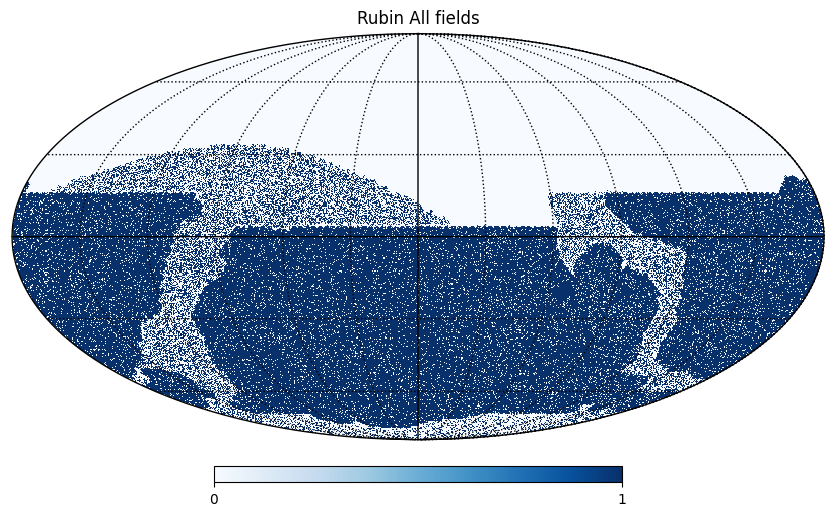

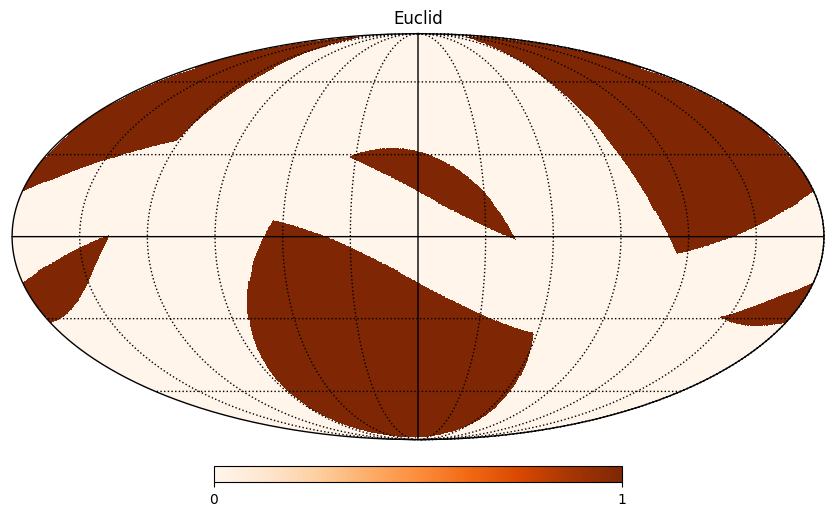

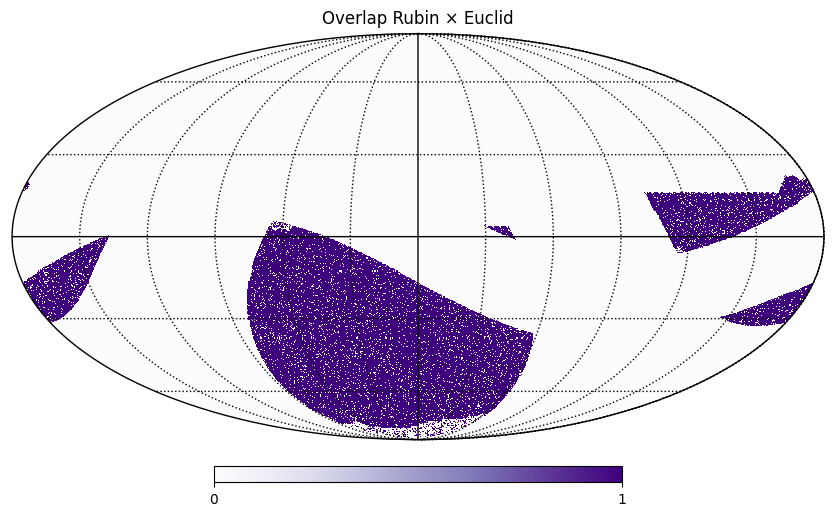

In [11]:
import matplotlib.pyplot as plt

hp.mollview(mask.astype(float), title="Rubin All fields",cmap="Blues")
hp.graticule(verbose=True)
hp.mollview(euclid_mask.astype(float), title="Euclid",cmap="Oranges")
hp.graticule(verbose=True)
hp.mollview(overlap.astype(float), title="Overlap Rubin × Euclid",cmap="Purples")
hp.graticule(verbose=True)
plt.show()

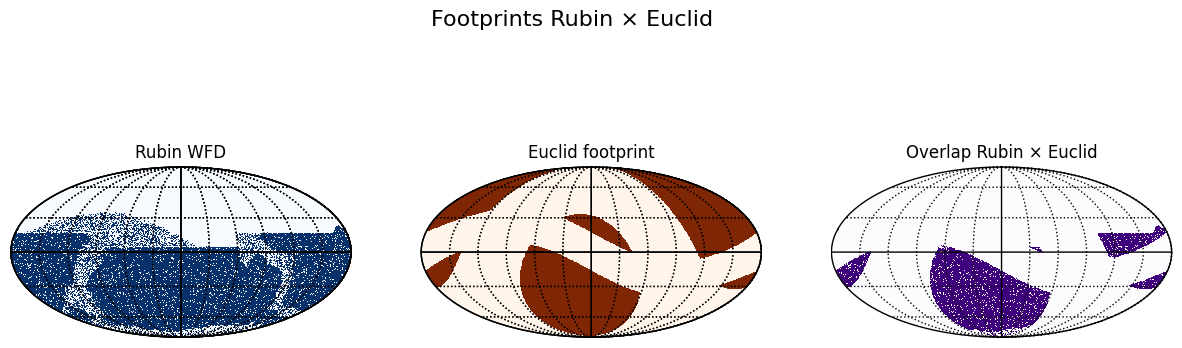

In [12]:
import healpy as hp
import matplotlib.pyplot as plt

# Listes des cartes et titres
maps = [mask, euclid_mask, overlap]
titles = ["Rubin WFD", "Euclid footprint", "Overlap Rubin × Euclid"]
cmaps = ["Blues", "Oranges", "Purples"]

plt.figure(figsize=(15,5))

for i, (m, title, cmap) in enumerate(zip(maps, titles, cmaps), 1):
    plt.subplot(1,3,i)
    hp.mollview(
        m.astype(float), 
        title=title,
        cmap=cmap,
        min=0, max=1,
        cbar=False,
        notext=True,
        hold=True
    )
    hp.graticule(verbose=False)

plt.suptitle("Footprints Rubin × Euclid", fontsize=16)
plt.show()

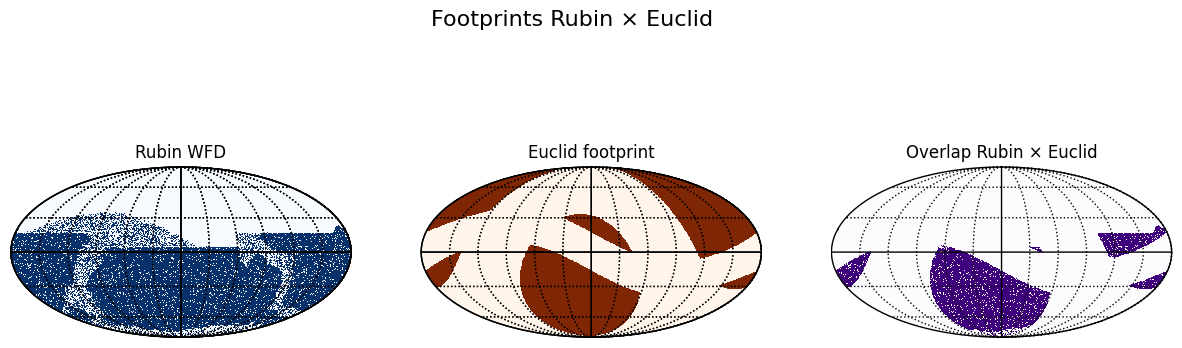

In [13]:
import healpy as hp
import matplotlib.pyplot as plt

# Listes des cartes et titres
maps = [mask, euclid_mask, overlap]
titles = ["Rubin WFD", "Euclid footprint", "Overlap Rubin × Euclid"]
cmaps = ["Blues", "Oranges", "Purples"]

plt.figure(figsize=(15,5))

for i, (m, title, cmap) in enumerate(zip(maps, titles, cmaps), 1):
    plt.subplot(1,3,i)
    hp.mollview(
        m.astype(float), 
        title=title,
        cmap=cmap,
        min=0, max=1,
        cbar=False,
        notext=True,
        hold=True
    )
    hp.graticule(verbose=True)

plt.suptitle("Footprints Rubin × Euclid", fontsize=16)
plt.show()

In [14]:
assert False

AssertionError: 

In [ ]:
# Notebook: Rubin WFD × Euclid Overlap Visualization (v5.0)
# ========================================================

import sqlite3
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.coordinates as coord

# ------------------------------
# 1. Paramètres HEALPix
# ------------------------------
nside = 256
npix = hp.nside2npix(nside)
pixarea = hp.nside2pixarea(nside, degrees=True)

# ------------------------------
# 2. Charger la base de données scheduler v5.0
# ------------------------------
#db_file = "baseline_v5.0.0_10yrs.db"  # à adapter selon votre téléchargement
db_file = file_cadence 
conn = sqlite3.connect(db_file)
cur = conn.cursor()

# ------------------------------
# 3. Lister les tables pour vérification
# ------------------------------
cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [t[0] for t in cur.fetchall()]
print("Tables dans le DB:", tables)

# ------------------------------
# 4. Extraire RA/Dec des observations WFD
# ------------------------------
query = """
SELECT f.ra, f.dec
FROM scheduled_observation AS s
JOIN field AS f ON s.fieldId = f.fieldId
WHERE f.fieldType='WFD'
"""
cur.execute(query)
data = np.array(cur.fetchall())
ra_list = data[:,0]
dec_list = data[:,1]
print(f"Nombre d'observations WFD: {len(ra_list)}")

# ------------------------------
# 5. Créer le masque HEALPix Rubin WFD
# ------------------------------
theta = np.radians(90 - dec_list)
phi = np.radians(ra_list)

pix_indices = hp.ang2pix(nside, theta, phi)
mask_rubin = np.zeros(npix, dtype=bool)
mask_rubin[pix_indices] = True

print("Surface Rubin WFD (deg²):", mask_rubin.sum()*pixarea)

# ------------------------------
# 6. Créer le masque Euclid (approximation galactique/ecliptique)
# ------------------------------
theta_pix, phi_pix = hp.pix2ang(nside, np.arange(npix))
ra_pix = np.degrees(phi_pix)
dec_pix = 90 - np.degrees(theta_pix)

sky = coord.SkyCoord(ra_pix*u.deg, dec_pix*u.deg)
b = sky.galactic.b.deg
beta = sky.barycentrictrueecliptic.lat.deg

mask_euclid = (np.abs(b) > 30) & (np.abs(beta) > 15)
print("Surface Euclid (deg²):", mask_euclid.sum()*pixarea)

# ------------------------------
# 7. Calculer l'overlap
# ------------------------------
overlap = mask_rubin & mask_euclid
print("Overlap Rubin × Euclid (deg²):", overlap.sum()*pixarea)

# ------------------------------
# 8. Visualisation améliorée
# ------------------------------
maps = [mask_rubin, mask_euclid, overlap]
titles = ["Rubin WFD", "Euclid footprint", "Overlap Rubin × Euclid"]
cmaps = ["Blues", "Oranges", "Purples"]

plt.figure(figsize=(18,6))

for i, (m, title, cmap) in enumerate(zip(maps, titles, cmaps), 1):
    plt.subplot(1,3,i)
    hp.mollview(
        m.astype(float),
        title=title,
        cmap=cmap,
        min=0, max=1,
        cbar=False,
        notext=True,
        hold=True
    )
    hp.graticule(verbose=False)

plt.suptitle("Footprints Rubin × Euclid (v5.0)", fontsize=18)
plt.tight_layout()
plt.show()

# ------------------------------
# 9. Optionnel: sauvegarder en FITS
# ------------------------------
hp.write_map("footprint_overlap.fits", overlap.astype(float), overwrite=True)
print("Carte HEALPix sauvegardée dans 'footprint_overlap.fits'")